## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000023C132CEF00> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623
1,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427
2,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.081799
3,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,1.822118
4,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,NaN,13895.000000,NaN,NaN,NaN,0.011088


In [6]:
wnv_file.head()

,nuts2,nuts3,dt_placement,cases
0,θεσσαλιας,καρδιτσας,2010-07,0
1,θεσσαλιας,καρδιτσας,2010-08,0
2,θεσσαλιας,καρδιτσας,2010-09,0
3,θεσσαλιας,καρδιτσας,2010-10,0
4,θεσσαλιας,καρδιτσας,2011-07,3


In [7]:
timeline_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3      dt_placement
λαρισας    2010-01-01      277
           2022-12-14      277
           2022-12-30      277
           2022-12-29      277
           2022-12-28      277
                          ... 
μαγνησιας  2010-01-05       96
           2010-01-04       96
           2010-01-10       96
           2010-01-19       96
           2010-01-01       96
Length: 18992, dtype: int64

In [8]:
wnv_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3      dt_placement
καρδιτσας  2010-07         1
           2010-08         1
           2010-09         1
           2010-10         1
           2011-07         1
           2011-08         1
           2011-09         1
           2011-10         1
           2018-07         1
           2018-08         1
           2018-09         1
           2022-10         1
           2018-10         1
           2019-08         1
           2019-09         1
           2019-10         1
           2020-07         1
           2020-08         1
           2020-09         1
           2020-10         1
           2022-07         1
           2022-08         1
           2019-07         1
           2022-09         1
λαρισας    2010-07         1
           2022-09         1
           2010-08         1
           2010-09         1
           2010-10         1
           2011-07         1
           2011-08         1
           2011-09         1
           2011-10         1
           2018-07 

In [9]:
#timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file = convert_temperature(timeline_file)

In [12]:
timeline_file

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.374623,NaN,NaN,NaN,NaN,NaN
1,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.121427,NaN,NaN,NaN,NaN,NaN
2,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,0.081799,NaN,NaN,NaN,NaN,NaN
3,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,1.822118,NaN,NaN,NaN,NaN,NaN
4,καρδιτσας,θεσσαλιας,21.742560,39.293760,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,NaN,4.750000,NaN,NaN,NaN,0.011088,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143171,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-27,27,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,13.570000,6.350000,11.359677,15.474286,16.000968,16.000968,1.918387,3.106429,2.502903,2.502903,0.000000,9.960000,6.639032,9.290357,9.251935,9.251935
3143172,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.570000,6.350000,11.359677,15.474286,16.000968,16.000968,1.918387,3.106429,2.502903,2.502903,0.000000,9.960000,6.639032,9.290357,9.251935,9.251935
3143173,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-29,29,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,13.090000,5.970000,11.359677,15.474286,16.000968,16.000968,1.918387,3.106429,2.502903,2.502903,0.000000,9.530000,6.639032,9.290357,9.251935,9.251935
3143174,τρικαλων,θεσσαλιας,22.119580,39.625550,2022-12-30,30,12,2022,0.192832,0.041302,-0.046541,-0.041302,0.244650,0.008412,-0.137017,-0.008412,0.055565,0.078895,0.094976,0.078895,10.650000,4.950000,11.359677,15.474286,16.000968,16.000968,1.918387,3.106429,2.502903,2.502903,0.000000,7.800000,6.639032,9.290357,9.251935,9.251935


In [13]:
grouped = timeline_file.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,2010-01-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.250750,NaN,16.250750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.050513,NaN,NaN,NaN,NaN,NaN
1,2010-01-01,λαρισας,θεσσαλιας,22.405497,39.703383,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.911704,5.846410,15.911704,NaN,NaN,NaN,5.846410,NaN,NaN,NaN,1.096759,10.423932,10.423932,NaN,NaN,NaN
2,2010-01-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.806170,7.386000,16.806170,NaN,NaN,NaN,7.386000,NaN,NaN,NaN,0.071117,11.800000,11.800000,NaN,NaN,NaN
3,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN
4,2010-01-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.369326,5.102464,14.331798,NaN,NaN,NaN,5.102464,NaN,NaN,NaN,15.711856,9.359322,9.821525,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,τρικαλων,θεσσαλιας,21.591863,39.641569,30.000000,12.000000,2022.000000,0.301352,0.101026,-0.231860,-0.101026,0.252016,0.118255,-0.185997,-0.118255,0.047931,0.058056,0.053729,0.058056,8.768434,2.807470,7.439471,10.485465,9.749806,9.749806,0.546708,0.878007,-0.150506,-0.150506,0.000000,5.787952,3.993090,5.710016,4.799650,4.799650
18988,2022-12-31,καρδιτσας,θεσσαλιας,21.891852,39.318887,31.000000,12.000000,2022.000000,0.268452,0.059572,-0.203921,-0.059572,0.240353,0.061059,-0.178930,-0.061059,0.052645,0.050411,0.051347,0.050411,10.315366,3.485447,8.451243,11.876045,12.131269,12.131269,0.996635,1.669135,1.084576,1.084576,0.000000,6.900407,4.723939,6.772590,6.607923,6.607923
18989,2022-12-31,λαρισας,θεσσαλιας,22.405497,39.703383,31.000000,12.000000,2022.000000,0.322494,0.053153,-0.252553,-0.053153,0.311524,0.056624,-0.241544,-0.056624,0.051063,0.060420,0.046550,0.060420,11.524152,3.627690,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,0.000000,7.575921,5.033156,7.404144,7.301386,7.301386
18990,2022-12-31,μαγνησιας,θεσσαλιας,22.869212,39.281871,31.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.015417,5.194583,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.105000,6.255748,7.679111,6.719997,6.719997


In [14]:
dataset = pd.DataFrame()
groups = dataset_grouped.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

In [15]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN,39.913539,39.913539,39.913539
1,2010-01-02,τρικαλων,θεσσαλιας,21.591863,39.641569,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.769065,3.856250,11.675701,NaN,NaN,NaN,3.963542,NaN,NaN,NaN,9.773641,8.803333,9.108333,NaN,NaN,NaN,49.687179,49.687179,49.687179
2,2010-01-03,τρικαλων,θεσσαλιας,21.591863,39.641569,3.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.418475,0.067000,9.814972,NaN,NaN,NaN,0.654667,NaN,NaN,NaN,0.773894,4.954545,6.032591,NaN,NaN,NaN,50.461073,50.461073,50.461073
3,2010-01-04,τρικαλων,θεσσαλιας,21.591863,39.641569,4.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.067000,9.268347,NaN,NaN,NaN,0.492250,NaN,NaN,NaN,0.767006,4.805357,5.596585,NaN,NaN,NaN,51.228079,51.228079,51.228079
4,2010-01-05,τρικαλων,θεσσαλιας,21.591863,39.641569,5.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.085172,9.057517,NaN,NaN,NaN,0.390184,NaN,NaN,NaN,0.299098,4.702193,5.335838,NaN,NaN,NaN,51.527177,51.527177,51.527177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,μαγνησιας,θεσσαλιας,22.869212,39.281871,27.000000,12.000000,2022.000000,0.306354,0.142721,-0.226513,-0.142721,0.295556,0.129420,-0.222720,-0.129420,0.050034,0.053908,0.048828,0.053908,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,1.631371,1046.578644
18988,2022-12-28,μαγνησιας,θεσσαλιας,22.869212,39.281871,28.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,0.034196,1046.578644
18989,2022-12-29,μαγνησιας,θεσσαλιας,22.869212,39.281871,29.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.886875,5.612708,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.749792,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644
18990,2022-12-30,μαγνησιας,θεσσαλιας,22.869212,39.281871,30.000000,12.000000,2022.000000,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644


In [16]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [17]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [18]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN,39.913539,39.913539,39.913539
1,2010-01-02,τρικαλων,θεσσαλιας,21.591863,39.641569,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.769065,3.856250,11.675701,NaN,NaN,NaN,3.963542,NaN,NaN,NaN,9.773641,8.803333,9.108333,NaN,NaN,NaN,49.687179,49.687179,49.687179
2,2010-01-03,τρικαλων,θεσσαλιας,21.591863,39.641569,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.418475,0.067000,9.814972,NaN,NaN,NaN,0.654667,NaN,NaN,NaN,0.773894,4.954545,6.032591,NaN,NaN,NaN,50.461073,50.461073,50.461073
3,2010-01-04,τρικαλων,θεσσαλιας,21.591863,39.641569,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.067000,9.268347,NaN,NaN,NaN,0.492250,NaN,NaN,NaN,0.767006,4.805357,5.596585,NaN,NaN,NaN,51.228079,51.228079,51.228079
4,2010-01-05,τρικαλων,θεσσαλιας,21.591863,39.641569,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.085172,9.057517,NaN,NaN,NaN,0.390184,NaN,NaN,NaN,0.299098,4.702193,5.335838,NaN,NaN,NaN,51.527177,51.527177,51.527177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,μαγνησιας,θεσσαλιας,22.869212,39.281871,27,12,2022,0.306354,0.142721,-0.226513,-0.142721,0.295556,0.129420,-0.222720,-0.129420,0.050034,0.053908,0.048828,0.053908,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,1.631371,1046.578644
18988,2022-12-28,μαγνησιας,θεσσαλιας,22.869212,39.281871,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,0.034196,1046.578644
18989,2022-12-29,μαγνησιας,θεσσαλιας,22.869212,39.281871,29,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.886875,5.612708,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.749792,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644
18990,2022-12-30,μαγνησιας,θεσσαλιας,22.869212,39.281871,30,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644


In [19]:
dataset[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3      dt_placement
καρδιτσας  2010-01-01      1
           2010-01-03      1
           2010-01-05      1
           2010-01-06      1
           2010-01-07      1
                          ..
τρικαλων   2022-12-29      1
           2022-12-30      1
           2022-12-24      1
           2022-12-15      1
           2022-12-31      1
Length: 18992, dtype: int64

In [20]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,21.891852,39.318887,2010-01-01,1
1,22.405497,39.703383,2010-01-01,3
2,22.869212,39.281871,2010-01-01,1
3,21.591863,39.641569,2010-01-01,21
4,21.891852,39.318887,2010-01-02,1
...,...,...,...,...
18987,21.591863,39.641569,2022-12-30,444
18988,21.891852,39.318887,2022-12-31,180
18989,22.405497,39.703383,2022-12-31,206
18990,22.869212,39.281871,2022-12-31,62


In [21]:
df_mosquitoes['dt_placement'] = pd.to_datetime(df_mosquitoes['dt_placement'])

In [22]:
dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

df_mosquitoes['x.approx'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y.approx'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [23]:
dataset = pd.merge(dataset, df_mosquitoes,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

<AxesSubplot:>

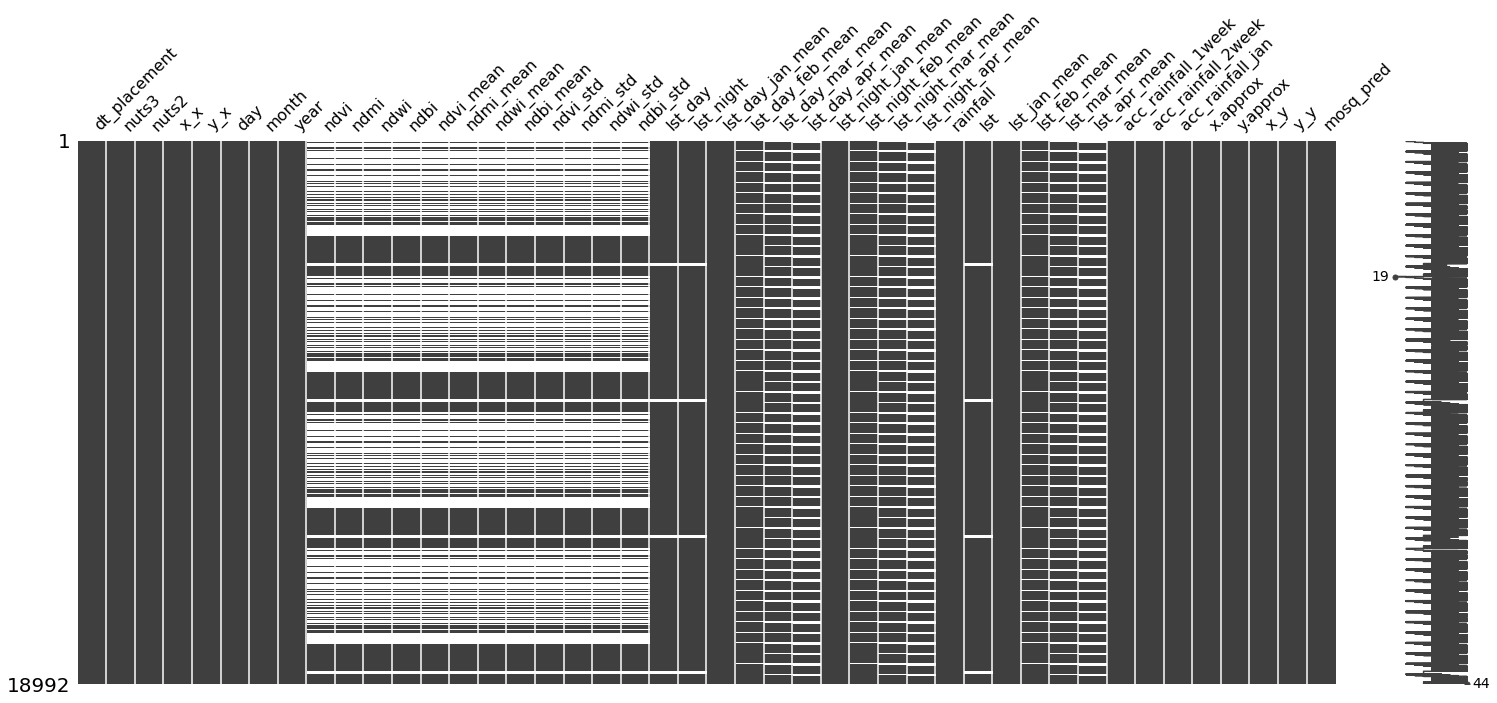

In [24]:
missingno.matrix(dataset)

In [25]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)


In [26]:
dataset.distance.max()

0.0

In [27]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [28]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred
0,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN,39.913539,39.913539,39.913539,21
1,2010-01-02,τρικαλων,θεσσαλιας,21.591863,39.641569,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.769065,3.856250,11.675701,NaN,NaN,NaN,3.963542,NaN,NaN,NaN,9.773641,8.803333,9.108333,NaN,NaN,NaN,49.687179,49.687179,49.687179,16
2,2010-01-03,τρικαλων,θεσσαλιας,21.591863,39.641569,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.418475,0.067000,9.814972,NaN,NaN,NaN,0.654667,NaN,NaN,NaN,0.773894,4.954545,6.032591,NaN,NaN,NaN,50.461073,50.461073,50.461073,10
3,2010-01-04,τρικαλων,θεσσαλιας,21.591863,39.641569,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.067000,9.268347,NaN,NaN,NaN,0.492250,NaN,NaN,NaN,0.767006,4.805357,5.596585,NaN,NaN,NaN,51.228079,51.228079,51.228079,1
4,2010-01-05,τρικαλων,θεσσαλιας,21.591863,39.641569,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.085172,9.057517,NaN,NaN,NaN,0.390184,NaN,NaN,NaN,0.299098,4.702193,5.335838,NaN,NaN,NaN,51.527177,51.527177,51.527177,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,μαγνησιας,θεσσαλιας,22.869212,39.281871,27,12,2022,0.306354,0.142721,-0.226513,-0.142721,0.295556,0.129420,-0.222720,-0.129420,0.050034,0.053908,0.048828,0.053908,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,1.631371,1046.578644,45
18988,2022-12-28,μαγνησιας,θεσσαλιας,22.869212,39.281871,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,0.034196,1046.578644,196
18989,2022-12-29,μαγνησιας,θεσσαλιας,22.869212,39.281871,29,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.886875,5.612708,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.749792,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,50
18990,2022-12-30,μαγνησιας,θεσσαλιας,22.869212,39.281871,30,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,53


In [29]:
bio_values = []

for region in dataset.nuts3.unique():
    for year in dataset.year.unique():
        for month in dataset.month.unique():
            filtered_df = dataset.loc[(dataset['year'] == year) & (dataset['nuts3'] == region) & (dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'nuts3': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [30]:
bio_values_df = pd.DataFrame(bio_values)

In [31]:
dataset = pd.merge(dataset, bio_values_df, on=['nuts3', 'year', 'month'], how='left')

In [32]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN,39.913539,39.913539,39.913539,21,-1.336788,15.217500,217.510733
1,2010-01-02,τρικαλων,θεσσαλιας,21.591863,39.641569,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.769065,3.856250,11.675701,NaN,NaN,NaN,3.963542,NaN,NaN,NaN,9.773641,8.803333,9.108333,NaN,NaN,NaN,49.687179,49.687179,49.687179,16,-1.336788,15.217500,217.510733
2,2010-01-03,τρικαλων,θεσσαλιας,21.591863,39.641569,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.418475,0.067000,9.814972,NaN,NaN,NaN,0.654667,NaN,NaN,NaN,0.773894,4.954545,6.032591,NaN,NaN,NaN,50.461073,50.461073,50.461073,10,-1.336788,15.217500,217.510733
3,2010-01-04,τρικαλων,θεσσαλιας,21.591863,39.641569,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.067000,9.268347,NaN,NaN,NaN,0.492250,NaN,NaN,NaN,0.767006,4.805357,5.596585,NaN,NaN,NaN,51.228079,51.228079,51.228079,1,-1.336788,15.217500,217.510733
4,2010-01-05,τρικαλων,θεσσαλιας,21.591863,39.641569,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.085172,9.057517,NaN,NaN,NaN,0.390184,NaN,NaN,NaN,0.299098,4.702193,5.335838,NaN,NaN,NaN,51.527177,51.527177,51.527177,1,-1.336788,15.217500,217.510733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,μαγνησιας,θεσσαλιας,22.869212,39.281871,27,12,2022,0.306354,0.142721,-0.226513,-0.142721,0.295556,0.129420,-0.222720,-0.129420,0.050034,0.053908,0.048828,0.053908,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,1.631371,1046.578644,45,1.944167,13.649167,11.989727
18988,2022-12-28,μαγνησιας,θεσσαλιας,22.869212,39.281871,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,0.034196,1046.578644,196,1.944167,13.649167,11.989727
18989,2022-12-29,μαγνησιας,θεσσαλιας,22.869212,39.281871,29,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.886875,5.612708,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.749792,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,50,1.944167,13.649167,11.989727
18990,2022-12-30,μαγνησιας,θεσσαλιας,22.869212,39.281871,30,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,53,1.944167,13.649167,11.989727


<AxesSubplot:>

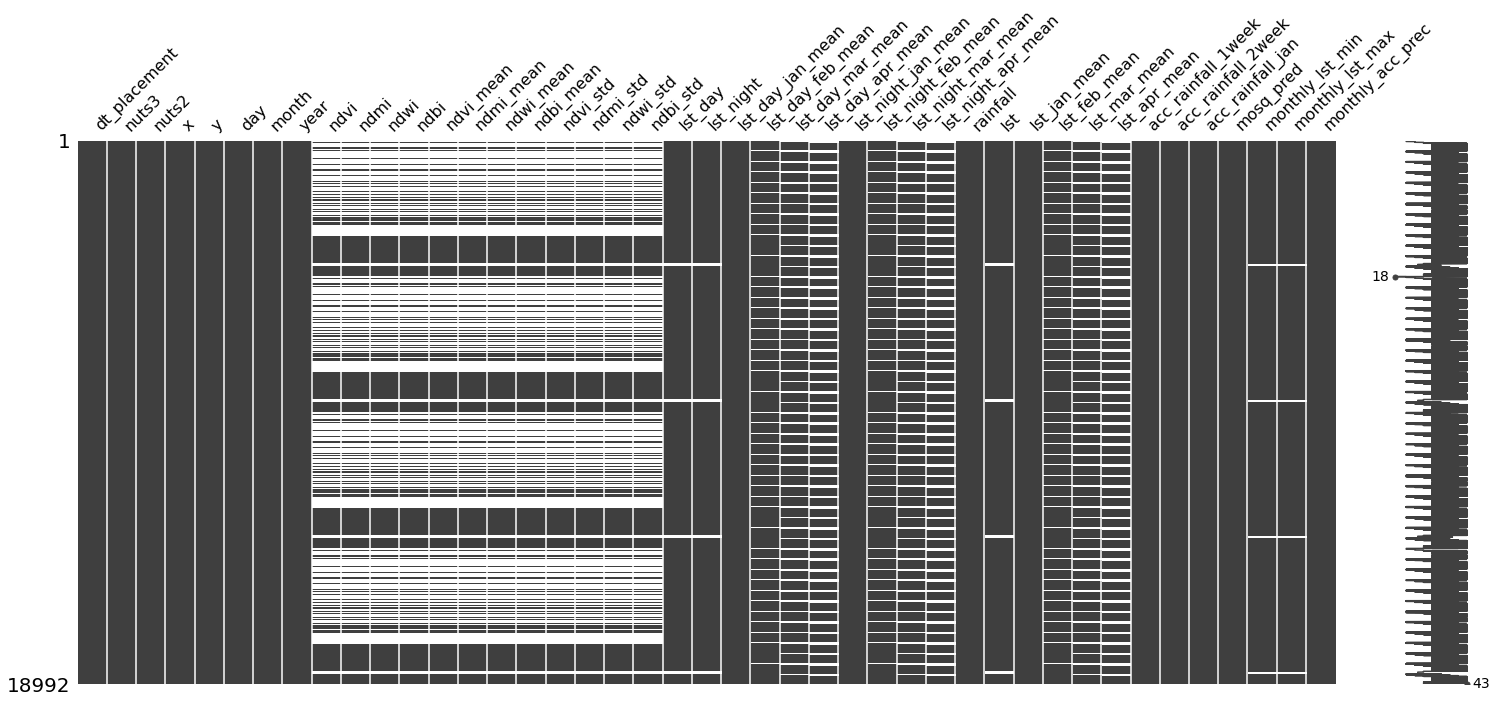

In [33]:
missingno.matrix(dataset)

In [34]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [35]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [36]:
dataset

,dt_placement_daily,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.217500,5.159474,15.217500,NaN,NaN,NaN,5.159474,NaN,NaN,NaN,39.913539,9.514444,9.514444,NaN,NaN,NaN,39.913539,39.913539,39.913539,21,-1.336788,15.217500,217.510733,2010-01
1,2010-01-02,τρικαλων,θεσσαλιας,21.591863,39.641569,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.769065,3.856250,11.675701,NaN,NaN,NaN,3.963542,NaN,NaN,NaN,9.773641,8.803333,9.108333,NaN,NaN,NaN,49.687179,49.687179,49.687179,16,-1.336788,15.217500,217.510733,2010-01
2,2010-01-03,τρικαλων,θεσσαλιας,21.591863,39.641569,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.418475,0.067000,9.814972,NaN,NaN,NaN,0.654667,NaN,NaN,NaN,0.773894,4.954545,6.032591,NaN,NaN,NaN,50.461073,50.461073,50.461073,10,-1.336788,15.217500,217.510733,2010-01
3,2010-01-04,τρικαλων,θεσσαλιας,21.591863,39.641569,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.067000,9.268347,NaN,NaN,NaN,0.492250,NaN,NaN,NaN,0.767006,4.805357,5.596585,NaN,NaN,NaN,51.228079,51.228079,51.228079,1,-1.336788,15.217500,217.510733,2010-01
4,2010-01-05,τρικαλων,θεσσαλιας,21.591863,39.641569,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.226000,0.085172,9.057517,NaN,NaN,NaN,0.390184,NaN,NaN,NaN,0.299098,4.702193,5.335838,NaN,NaN,NaN,51.527177,51.527177,51.527177,1,-1.336788,15.217500,217.510733,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,μαγνησιας,θεσσαλιας,22.869212,39.281871,27,12,2022,0.306354,0.142721,-0.226513,-0.142721,0.295556,0.129420,-0.222720,-0.129420,0.050034,0.053908,0.048828,0.053908,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,1.631371,1046.578644,45,1.944167,13.649167,11.989727,2022-12
18988,2022-12-28,μαγνησιας,θεσσαλιας,22.869212,39.281871,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.058750,6.385417,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,9.222083,6.255748,7.679111,6.719997,6.719997,0.000000,0.034196,1046.578644,196,1.944167,13.649167,11.989727,2022-12
18989,2022-12-29,μαγνησιας,θεσσαλιας,22.869212,39.281871,29,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,11.886875,5.612708,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,8.749792,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,50,1.944167,13.649167,11.989727,2022-12
18990,2022-12-30,μαγνησιας,θεσσαλιας,22.869212,39.281871,30,12,2022,0.314339,0.163494,-0.225655,-0.163494,0.282861,0.159271,-0.197829,-0.159271,0.044633,0.047758,0.045492,0.047758,10.192292,5.651667,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.000000,7.921979,6.255748,7.679111,6.719997,6.719997,0.000000,0.004880,1046.578644,53,1.944167,13.649167,11.989727,2022-12


In [37]:
grouped = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,1.000000,-0.476829,16.250750,193.790875
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,1.129032,-0.715704,15.911704,93.733414
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,1.000000,0.040625,16.806170,150.488717
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,2.419355,-1.336788,15.217500,217.510733
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,14.500000,2.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,4.642857,-2.275500,15.057154,257.271323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,2022-11,τρικαλων,θεσσαλιας,21.591863,39.641569,15.500000,11.000000,2022.000000,0.378173,0.096201,-0.319533,-0.096201,0.359400,0.101746,-0.299292,-0.101746,0.053390,0.065807,0.047239,0.065807,15.257936,6.837631,7.439471,10.485465,9.749806,9.749806,0.546708,0.878007,-0.150506,-0.150506,2.005458,11.047783,3.993090,5.710016,4.799650,4.799650,11.310600,21.191852,1009.375857,243.333333,2.024940,23.141928,54.147365
620,2022-12,καρδιτσας,θεσσαλιας,21.891852,39.318887,16.000000,12.000000,2022.000000,0.274794,0.058420,-0.211282,-0.058420,0.239602,0.052575,-0.180233,-0.052575,0.052938,0.051683,0.052562,0.051683,10.857450,3.684708,8.451243,11.876045,12.131269,12.131269,0.996635,1.669135,1.084576,1.084576,0.654235,7.271079,4.723939,6.772590,6.607923,6.607923,5.984060,12.953173,966.515250,199.096774,0.560081,12.757967,20.281276
621,2022-12,λαρισας,θεσσαλιας,22.405497,39.703383,16.000000,12.000000,2022.000000,0.265851,0.012696,-0.215917,-0.012696,0.254444,0.021740,-0.204841,-0.021740,0.047524,0.053628,0.045857,0.053628,11.956016,3.973712,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,0.573481,7.964864,5.033156,7.404144,7.301386,7.301386,4.991685,10.974653,1090.611468,220.419355,-0.000830,14.041480,17.777902
622,2022-12,μαγνησιας,θεσσαλιας,22.869212,39.281871,16.000000,12.000000,2022.000000,0.313504,0.146302,-0.230896,-0.146302,0.295752,0.133378,-0.219067,-0.133378,0.050730,0.054612,0.049472,0.054612,11.994640,5.842633,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.386765,8.918636,6.255748,7.679111,6.719997,6.719997,5.447013,14.214317,1043.594935,68.806452,1.944167,13.649167,11.989727


In [38]:
dataset_month_mosq

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,καρδιτσας,θεσσαλιας,678.647426,1218.885507,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,235.571301,57.169609,304.489643,0.000000,0.000000,0.000000,84.004482,0.000000,0.000000,0.000000,193.790875,139.125220,188.203942,0.000000,0.000000,0.000000,1205.254560,2069.842961,3326.226837,31,-14.781707,503.773250,6007.517133
1,2010-01,λαρισας,θεσσαλιας,694.570417,1230.804862,496,31,62310,0.000000,0.000000,0.000000,0.000000,-0.000830,0.894925,1.182465,-0.894925,0.000732,0.017660,0.010642,0.017660,314.377502,60.574929,393.786850,0.000000,0.000000,0.000000,100.956855,0.000000,0.000000,0.000000,93.733414,186.978977,246.880392,0.000000,0.000000,0.000000,553.023177,886.084723,1111.737243,35,-22.186823,493.262815,2905.735829
2,2010-01,μαγνησιας,θεσσαλιας,708.945558,1217.738015,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,310.959753,102.867667,386.930830,0.000000,0.000000,0.000000,151.980171,0.000000,0.000000,0.000000,150.488717,206.591324,269.145756,0.000000,0.000000,0.000000,929.003006,1485.297641,1727.675697,31,1.259375,520.991277,4665.150212
3,2010-01,τρικαλων,θεσσαλιας,669.347763,1228.888625,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.843209,38.008196,202.880580,0.000000,0.000000,0.000000,62.604538,0.000000,0.000000,0.000000,217.510733,104.326880,138.838308,0.000000,0.000000,0.000000,1347.626518,2422.139058,3893.618672,75,-41.440424,471.742500,6742.832738
4,2010-02,καρδιτσας,θεσσαλιας,612.971868,1100.928845,406,56,56280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,273.954814,59.752483,175.202618,206.516474,0.000000,0.000000,52.110233,12.642002,0.000000,0.000000,257.271323,168.382789,113.694260,111.151771,0.000000,0.000000,1850.523079,3644.102692,9122.212222,130,-63.714000,421.600325,7203.597054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,2022-11,τρικαλων,θεσσαλιας,647.755899,1189.247057,465,330,60660,9.076142,2.308815,-7.668795,-2.308815,8.625603,2.441899,-7.183018,-2.441899,1.281364,1.579358,1.133742,1.579358,457.738072,205.128916,223.184143,314.563941,292.494170,292.494170,16.401244,26.340195,-4.515188,-4.515188,54.147365,331.433494,119.792693,171.300487,143.989491,143.989491,339.317988,635.755557,30281.275725,7300,60.748193,694.257831,1624.420938
620,2022-12,καρδιτσας,θεσσαλιας,678.647426,1218.885507,496,372,62682,6.320254,1.343663,-4.859481,-1.343663,5.510851,1.209230,-4.145352,-1.209230,1.217584,1.188717,1.208918,1.188717,238.863902,81.063577,261.988537,368.157404,376.069350,376.069350,30.895691,51.743177,33.621870,33.621870,20.281276,159.963740,146.442114,209.950290,204.845610,204.845610,185.505846,401.548366,29961.972755,6172,17.362520,395.496992,628.719557
621,2022-12,λαρισας,θεσσαλιας,694.570417,1230.804862,496,372,62682,6.114566,0.292008,-4.966094,-0.292008,5.852209,0.500021,-4.711345,-0.500021,1.093045,1.233441,1.054702,1.233441,263.032347,87.421661,299.478763,416.350144,436.824079,436.824079,12.576931,42.706786,15.861841,15.861841,17.777902,175.227004,156.027847,229.528465,226.342960,226.342960,154.742245,340.214242,33808.955514,6833,-0.025740,435.285884,551.114976
622,2022-12,μαγνησιας,θεσσαλιας,708.945558,1217.738015,49

In [39]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [40]:
wnv_file.head(5)

,nuts2,nuts3,dt_placement,cases
0,θεσσαλιας,καρδιτσας,2010-07,0
1,θεσσαλιας,καρδιτσας,2010-08,0
2,θεσσαλιας,καρδιτσας,2010-09,0
3,θεσσαλιας,καρδιτσας,2010-10,0
4,θεσσαλιας,καρδιτσας,2011-07,3


In [41]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        624 non-null    period[M]
 1   nuts3               624 non-null    object   
 2   nuts2               624 non-null    object   
 3   x                   624 non-null    float64  
 4   y                   624 non-null    float64  
 5   day                 624 non-null    float64  
 6   month               624 non-null    float64  
 7   year                624 non-null    float64  
 8   ndvi                609 non-null    float64  
 9   ndmi                609 non-null    float64  
 10  ndwi                609 non-null    float64  
 11  ndbi                609 non-null    float64  
 12  ndvi_mean           612 non-null    float64  
 13  ndmi_mean           612 non-null    float64  
 14  ndwi_mean           612 non-null    float64  
 15  ndbi_mean           612

In [42]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nuts2         96 non-null     object
 1   nuts3         96 non-null     object
 2   dt_placement  96 non-null     object
 3   cases         96 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 3.1+ KB


In [43]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [44]:
wnv_file

,nuts2,nuts3,dt_placement,cases
0,θεσσαλιας,καρδιτσας,2010-07,0
1,θεσσαλιας,καρδιτσας,2010-08,0
2,θεσσαλιας,καρδιτσας,2010-09,0
3,θεσσαλιας,καρδιτσας,2010-10,0
4,θεσσαλιας,καρδιτσας,2011-07,3
5,θεσσαλιας,καρδιτσας,2011-08,4
6,θεσσαλιας,καρδιτσας,2011-09,2
7,θεσσαλιας,καρδιτσας,2011-10,0
8,θεσσαλιας,καρδιτσας,2018-07,0
9,θεσσαλιας,καρδιτσας,2018-08,0


In [45]:
wnv_file['cases'].value_counts()

0     63
1      8
2      7
4      5
3      3
5      3
7      2
6      2
15     1
19     1
23     1
Name: cases, dtype: int64

In [46]:
wnv_file.cases.sum()

149

In [47]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'nuts3', 'nuts2'] )

In [48]:
merged

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,31,-0.476829,16.250750,193.790875,NaN
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,35,-0.715704,15.911704,93.733414,NaN
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,NaN
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,75,-1.336788,15.217500,217.510733,NaN
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,14.500000,2.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,130,-2.275500,15.057154,257.271323,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,2022-11,τρικαλων,θεσσαλιας,21.591863,39.641569,15.500000,11.000000,2022.000000,0.378173,0.096201,-0.319533,-0.096201,0.359400,0.101746,-0.299292,-0.101746,0.053390,0.065807,0.047239,0.065807,15.257936,6.837631,7.439471,10.485465,9.749806,9.749806,0.546708,0.878007,-0.150506,-0.150506,2.005458,11.047783,3.993090,5.710016,4.799650,4.799650,11.310600,21.191852,1009.375857,7300,2.024940,23.141928,54.147365,NaN
620,2022-12,καρδιτσας,θεσσαλιας,21.891852,39.318887,16.000000,12.000000,2022.000000,0.274794,0.058420,-0.211282,-0.058420,0.239602,0.052575,-0.180233,-0.052575,0.052938,0.051683,0.052562,0.051683,10.857450,3.684708,8.451243,11.876045,12.131269,12.131269,0.996635,1.669135,1.084576,1.084576,0.654235,7.271079,4.723939,6.772590,6.607923,6.607923,5.984060,12.953173,966.515250,6172,0.560081,12.757967,20.281276,NaN
621,2022-12,λαρισας,θεσσαλιας,22.405497,39.703383,16.000000,12.000000,2022.000000,0.265851,0.012696,-0.215917,-0.012696,0.254444,0.021740,-0.204841,-0.021740,0.047524,0.053628,0.045857,0.053628,11.956016,3.973712,9.660605,13.430650,14.091099,14.091099,0.405707,1.377638,0.511672,0.511672,0.573481,7.964864,5.033156,7.404144,7.301386,7.301386,4.991685,10.974653,1090.611468,6833,-0.000830,14.041480,17.777902,NaN
622,2022-12,μαγνησιας,θεσσαλιας,22.869212,39.281871,16.000000,12.000000,2022.000000,0.313504,0.146302,-0.230896,-0.146302,0.295752,0.133378,-0.219067,-0.133378,0.050730,0.054612,0.049472,0.054612,11.994640,5.842633,9.211819,11.741719,11.049724,11.049724,3.299677,3.616503,2.390269,2.390269,0.386765,8.918636,6.255748,7.679111,6.719997,6.719997,5.447013,14.214317,1043.594935,2133,1.944167,13.649167,11.989727,NaN


In [49]:
merged = fillna(merged,{'cases': 0})

In [50]:
merged['cases'].value_counts()

0.000000     591
1.000000       8
2.000000       7
4.000000       5
5.000000       3
3.000000       3
7.000000       2
6.000000       2
15.000000      1
19.000000      1
23.000000      1
Name: cases, dtype: int64

In [51]:
merged.cases.sum()

149.0

In [52]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [53]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

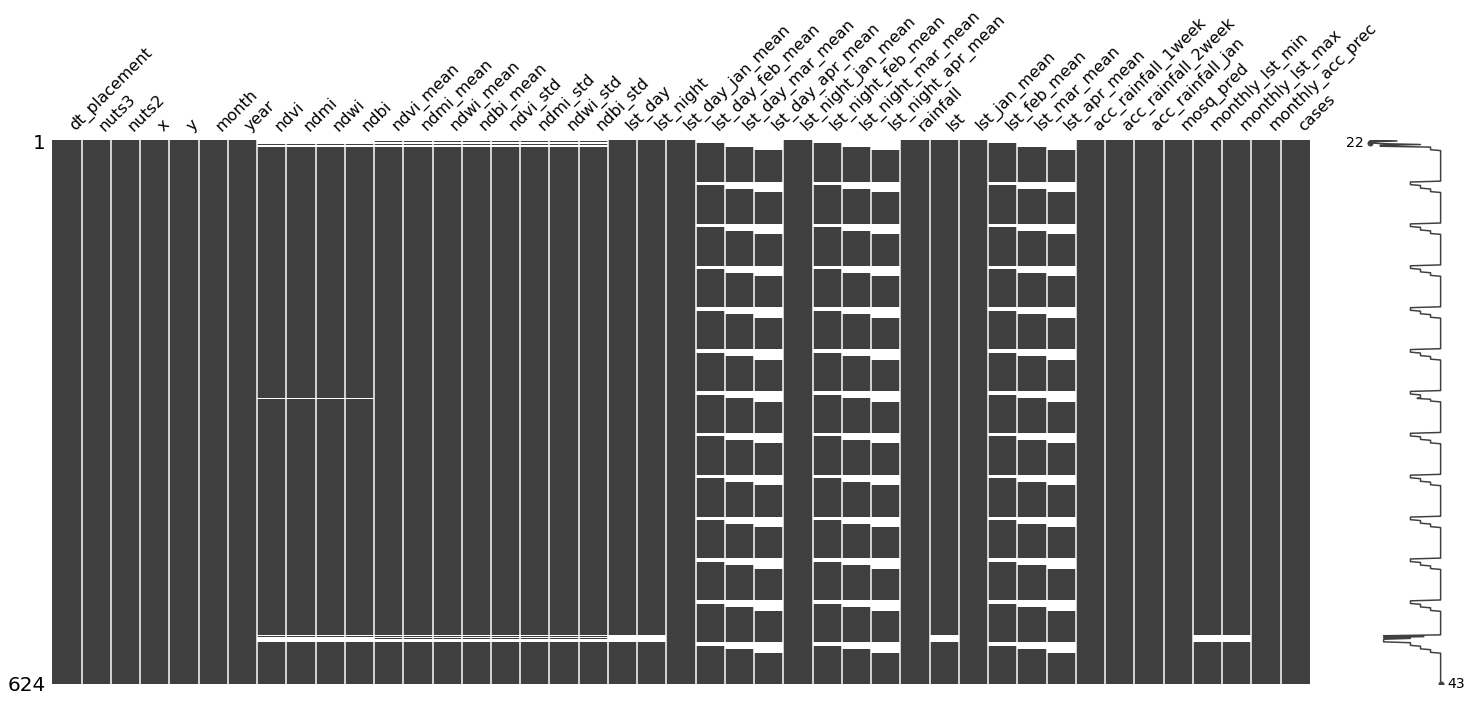

In [54]:
missingno.matrix(merged)

In [55]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,2.403800
8,ndmi,2.403800
9,ndwi,2.403800


In [56]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [57]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,2.403800
8,ndmi,2.403800
9,ndwi,2.403800


In [58]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [59]:
nuts3_units = merged.nuts3.unique()
nuts3_units

array(['καρδιτσας', 'λαρισας', 'μαγνησιας', 'τρικαλων'], dtype=object)

In [60]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['nuts3'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'nuts3': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [61]:
biovars_df.head(20)

,nuts3,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,καρδιτσας,2010,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000
1,λαρισας,2010,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000
2,μαγνησιας,2010,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
3,τρικαλων,2010,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000
4,καρδιτσας,2011,14.750000,19.333333,49.572650,842.749828,36.000000,-3.000000,39.000000,4.666667,25.166667,25.166667,4.666667,1120.000000,180.000000,1.000000,65.198982,426.000000,76.000000,76.000000,426.000000
5,λαρισας,2011,15.916667,22.500000,48.913043,906.249347,42.000000,-4.000000,46.000000,10.166667,27.333333,27.333333,5.666667,928.000000,123.000000,4.000000,50.136650,314.000000,136.000000,136.000000,284.000000
6,μαγνησιας,2011,15.583333,18.666667,47.863248,831.163843,37.000000,-2.000000,39.000000,7.166667,26.000000,26.000000,6.166667,1083.000000,180.000000,1.000000,59.487453,449.000000,124.000000,124.000000,381.000000
7,τρικαλων,2011,13.416667,19.333333,48.333333,846.874825,35.000000,-5.000000,40.000000,3.500000,23.833333,23.833333,3.500000,1301.000000,239.000000,3.000000,63.243204,507.000000,102.000000,102.000000,507.000000
8,καρδιτσας,2012,16.541667,20.750000,44.148936,910.908221,40.000000,-7.000000,47.000000,12.666667,27.166667,27.166667,4.666667,1505.000000,291.000000,5.000000,70.339023,645.000000,39.000000,39.000000,608.000000
9,λαρισας,2012,17.750000,24.000000,46.153846,944.722181,45.000000,-7.000000,52.000000,13.666667,28.833333,28.833333,5.666667,1276.000000,185.000000,7.000000,65.541262,502.000000,54.000000,54.000000,422.000000


In [62]:
merged = pd.merge(merged, biovars_df,  how='left', on=['nuts3', 'year'])

In [67]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['nuts3'] == 'μαγνησιας')]

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
6,2010-02,μαγνησιας,θεσσαλιας,22.869212,39.281871,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.283701,4.008292,10.029293,8.729393,NaN,NaN,3.192098,2.159872,NaN,NaN,5.881156,7.677793,6.610695,5.482965,NaN,NaN,44.165761,96.065976,244.542873,42,-1.225532,16.916667,164.672355,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
10,2010-03,μαγνησιας,θεσσαλιας,22.869212,39.281871,3,2010,0.452884,0.178015,-0.250841,-0.178015,0.451490,0.169616,-0.260363,-0.169616,0.055594,0.064438,0.052520,0.064438,17.126095,6.255880,10.029293,11.302252,16.259062,NaN,3.192098,4.026991,6.174462,NaN,3.380411,11.690988,6.610695,7.664621,11.216762,NaN,24.672636,52.868157,394.698300,95,3.004583,22.781042,104.792733,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
14,2010-04,μαγνησιας,θεσσαλιας,22.869212,39.281871,4,2010,0.450410,0.193727,-0.230506,-0.193727,0.444450,0.196812,-0.219064,-0.196812,0.044320,0.045770,0.035726,0.045770,21.062153,8.381528,10.029293,11.302252,17.126095,20.260892,3.192098,4.026991,6.255880,8.150235,1.047775,14.721840,6.610695,7.664621,11.690988,14.205563,7.241146,12.815931,431.679205,125,6.060208,26.733333,31.433250,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
18,2010-05,μαγνησιας,θεσσαλιας,22.869212,39.281871,5,2010,0.476249,0.170362,-0.304394,-0.170362,0.471905,0.172030,-0.297924,-0.172030,0.049364,0.048726,0.035680,0.048726,28.177708,14.449194,10.029293,11.302252,17.126095,17.126095,3.192098,4.026991,6.255880,6.255880,3.630348,21.313451,6.610695,7.664621,11.690988,11.690988,24.822328,46.670228,499.698725,200,11.982500,33.812917,112.540788,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
22,2010-06,μαγνησιας,θεσσαλιας,22.869212,39.281871,6,2010,0.431237,0.117806,-0.312624,-0.117806,0.429600,0.116616,-0.312705,-0.116616,0.050135,0.048001,0.028900,0.048001,31.079597,17.435583,10.029293,11.302252,17.126095,17.126095,3.192098,4.026991,6.255880,6.255880,2.009728,24.257590,6.610695,7.664621,11.690988,11.690988,14.314186,31.160757,600.782582,224,14.680000,37.887708,60.291841,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000
26,2010-07,μαγνησιας,θεσσαλιας,22.869212,39.281871,7,2010,0.418307,0.113616,-0.304837,-0.113616,0.414859,0.116848,-0.297654,-0.1168

In [91]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [92]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [93]:
# df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()
##replace nuts3 code with the correct one
df_demographics_nuts2 = df_demographics.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [94]:
code_to_name = {
    'EL611': 'καρδιτσας',
    'EL612': 'λαρισας',
    'EL613': 'μαγνησιας'
}

df_demographics_nuts2['NUTS3_NAME'] = df_demographics_nuts2['NUTS3_CODE'].map(code_to_name)

In [95]:
# df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)
df_demographics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [96]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,26640.000000,85703.000000,18953.000000,131296.000000,24896.000000,83120.000000,24351.000000,132367.000000,καρδιτσας
1,1992,25762.000000,85463.000000,19664.000000,130889.000000,24202.000000,83240.000000,25158.000000,132600.000000,καρδιτσας
2,1993,25024.000000,85047.000000,20234.000000,130305.000000,23588.000000,83211.000000,25733.000000,132532.000000,καρδιτσας
3,1994,24219.000000,84560.000000,20939.000000,129718.000000,22831.000000,83067.000000,26338.000000,132236.000000,καρδιτσας
4,1995,23382.000000,84236.000000,21204.000000,128822.000000,22192.000000,83148.000000,26622.000000,131962.000000,καρδιτσας
5,1996,22660.000000,83593.000000,21693.000000,127946.000000,21379.000000,83147.000000,27166.000000,131692.000000,καρδιτσας
6,1997,21902.000000,82659.000000,22250.000000,126811.000000,20761.000000,83017.000000,27536.000000,131314.000000,καρδιτσας
7,1998,21094.000000,81944.000000,22708.000000,125746.000000,20168.000000,82670.000000,28093.000000,130931.000000,καρδιτσας
8,1999,20428.000000,80994.000000,23205.000000,124627.000000,19621.000000,82329.000000,28541.000000,130491.000000,καρδιτσας
9,2000,19799.000000,79438.000000,23905.000000,123142.000000,19116.000000,81502.000000,29349.000000,129967.000000,καρδιτσας


In [102]:
## specific to thessaly

df_demographics_nuts2_trikala = df_demographics_nuts2.loc[df_demographics_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_demographics_nuts2_trikala['nuts3'] = 'τρικαλων'

df_demographics_nuts2 = df_demographics_nuts2.append(df_demographics_nuts2_trikala, ignore_index = True)

In [103]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,26640.000000,85703.000000,18953.000000,131296.000000,24896.000000,83120.000000,24351.000000,132367.000000,καρδιτσας
1,1992,25762.000000,85463.000000,19664.000000,130889.000000,24202.000000,83240.000000,25158.000000,132600.000000,καρδιτσας
2,1993,25024.000000,85047.000000,20234.000000,130305.000000,23588.000000,83211.000000,25733.000000,132532.000000,καρδιτσας
3,1994,24219.000000,84560.000000,20939.000000,129718.000000,22831.000000,83067.000000,26338.000000,132236.000000,καρδιτσας
4,1995,23382.000000,84236.000000,21204.000000,128822.000000,22192.000000,83148.000000,26622.000000,131962.000000,καρδιτσας
...,...,...,...,...,...,...,...,...,...,...
123,2018,15551.000000,71019.000000,30300.000000,116870.000000,14670.000000,68814.000000,36026.000000,119510.000000,τρικαλων
124,2019,15273.000000,70165.000000,30508.000000,115946.000000,14338.000000,68116.000000,36045.000000,118499.000000,τρικαλων
125,2020,14936.000000,69399.000000,30620.000000,114955.000000,14081.000000,67437.000000,35957.000000,117475.000000,τρικαλων
126,2021,14610.000000,68583.000000,30631.000000,113824.000000,13766.000000,66633.000000,35877.000000,116276.000000,τρικαλων


In [104]:
names_from_merged = merged["nuts3"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [105]:
# df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [106]:
# names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
# names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_merged:
#     if element not in names_from_demographics:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [107]:
dataset = pd.merge(merged, df_demographics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

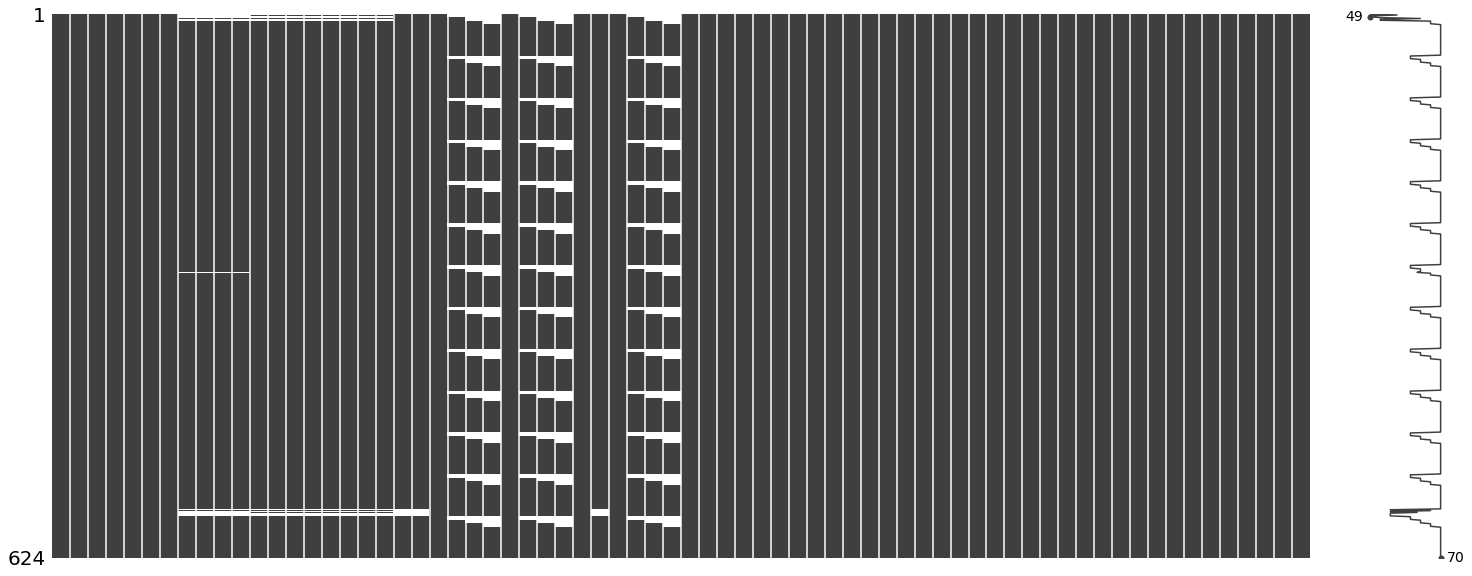

In [108]:
missingno.matrix(dataset)

In [109]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [110]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [111]:
## chose the right NUTS2 Code

df_economics_nuts2 = df_economics.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [112]:
df_economics_nuts2['NUTS3_NAME'] = df_economics_nuts2['NUTS3_CODE'].map(code_to_name)
df_economics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_economics_nuts2.reset_index(inplace=True, drop=True)
df_economics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [113]:
df_economics_nuts2

,year,MIO_EUR,nuts3
0,2000,2133.000000,καρδιτσας
1,2001,2333.720000,καρδιτσας
2,2002,2471.530000,καρδιτσας
3,2003,2738.630000,καρδιτσας
4,2004,2905.000000,καρδιτσας
5,2005,2846.530000,καρδιτσας
6,2006,2957.160000,καρδιτσας
7,2007,3192.360000,καρδιτσας
8,2008,3254.090000,καρδιτσας
9,2009,3296.180000,καρδιτσας


In [116]:
## specific to thessaly

df_economics_nuts2_trikala = df_economics_nuts2.loc[df_economics_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_economics_nuts2_trikala['nuts3'] = 'τρικαλων'

df_economics_nuts2 = df_economics_nuts2.append(df_economics_nuts2_trikala, ignore_index = True)

In [117]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_economics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [118]:
dataset = pd.merge(dataset, df_economics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

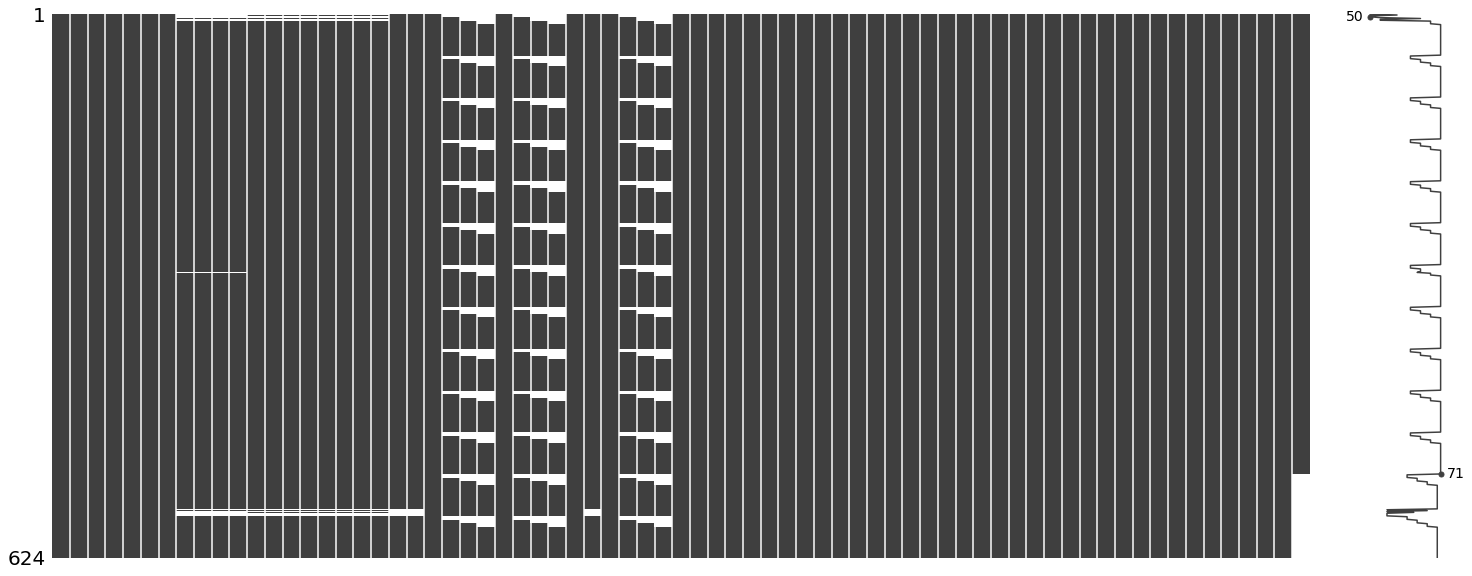

In [119]:
missingno.matrix(dataset)

In [120]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [121]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [122]:
df_trade_nuts2 = df_trade.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [123]:
df_trade_nuts2['NUTS3_NAME'] = df_trade_nuts2['NUTS3_CODE'].map(code_to_name)
df_trade_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_trade_nuts2.reset_index(inplace=True, drop=True)
df_trade_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [124]:
df_trade_nuts2

,year,L_TOTAL,UNL_TOTAL,nuts3
0,2015,10352.000000,10375.000000,καρδιτσας
1,2016,23404.000000,23165.000000,καρδιτσας
2,2017,7816.000000,7614.000000,καρδιτσας
3,2018,5407.000000,5526.000000,καρδιτσας
4,2019,10375.000000,9909.000000,καρδιτσας
5,2020,8644.000000,7197.000000,καρδιτσας
6,2021,6070.000000,6292.000000,καρδιτσας
7,2015,7604.000000,8362.000000,λαρισας
8,2016,5898.000000,5977.000000,λαρισας
9,2017,4061.000000,4578.000000,λαρισας


In [126]:
## specific to thessaly

df_trade_nuts2_trikala = df_trade_nuts2.loc[df_trade_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_trade_nuts2_trikala['nuts3'] = 'τρικαλων'

df_trade_nuts2 = df_trade_nuts2.append(df_trade_nuts2_trikala, ignore_index = True)

In [127]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_trade_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [128]:
dataset = pd.merge(dataset, df_trade_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

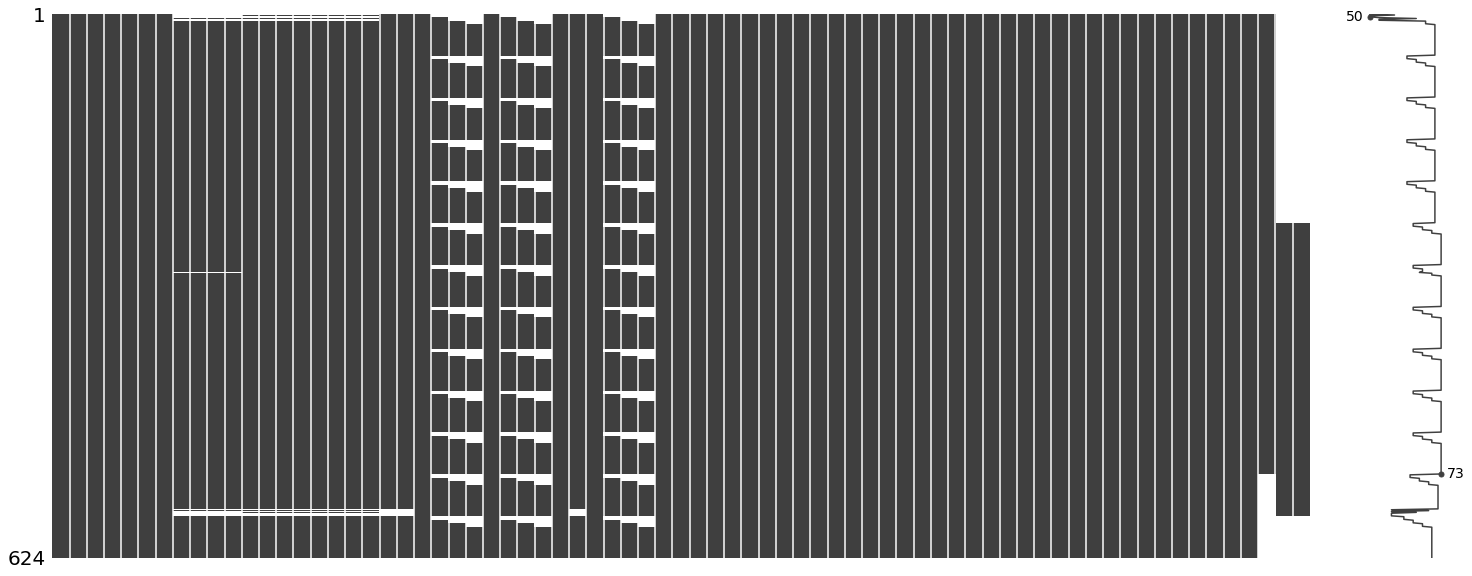

In [129]:
missingno.matrix(dataset)

In [130]:
missing = describe_dataframe(dataset)

In [131]:
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,2.403800
8,ndmi,2.403800
9,ndwi,2.403800


In [132]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,31,-0.476829,16.250750,193.790875,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,35,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,75,-1.336788,15.217500,217.510733,0,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,130,-2.275500,15.057154,257.271323,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [133]:
dataset.reset_index(inplace=True, drop=True)

In [134]:
dataset['cases'].value_counts()

0     591
1       8
2       7
4       5
5       3
3       3
7       2
6       2
15      1
19      1
23      1
Name: cases, dtype: int64

In [135]:
dataset['cases'].sum()

149

In [136]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,31,-0.476829,16.250750,193.790875,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,35,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,75,-1.336788,15.217500,217.510733,0,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,130,-2.275500,15.057154,257.271323,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [137]:
cols = dataset.columns

In [138]:
cols

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'month', 'year', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean',
       'lst_day_apr_mean', 'lst_night_jan_mean', 'lst_night_feb_mean',
       'lst_night_mar_mean', 'lst_night_apr_mean', 'rainfall', 'lst',
       'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec',
       'cases', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
       'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65',
       'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 'MIO_EUR',
       'L_TOTAL', 'UNL_TOTAL']

In [139]:
len(cols)

73

In [140]:
# check columns

In [141]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'nuts2', 'nuts3',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean', 'lst_day_apr_mean', 
                 'lst_night_jan_mean', 'lst_night_feb_mean', 'lst_night_mar_mean', 'lst_night_apr_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [142]:
len(final_columns)

73

In [143]:
dataset_final = dataset[final_columns].copy()

In [144]:
dataset_final

,x,y,month,year,dt_placement,nuts2,nuts3,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,21.891852,39.318887,1,2010,2010-01,θεσσαλιας,καρδιτσας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,4.637507,7.599074,1.905654,-0.476829,16.250750,6.273465,NaN,NaN,NaN,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,193.790875,38.879179,66.769128,107.297640,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,31,0
1,22.405497,39.703383,1,2010,2010-01,θεσσαλιας,λαρισας,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.031580,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,35,0
2,22.869212,39.281871,1,2010,2010-01,θεσσαλιας,μαγνησιας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,6.664236,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN,31,0
3,21.591863,39.641569,1,2010,2010-01,θεσσαλιας,τρικαλων,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,3.365383,5.156233,1.226071,-1.336788,15.217500,4.478655,NaN,NaN,NaN,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,217.510733,43.471823,78.133518,125.600602,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,75,0
4,21.891852,39.318887,2,2010,2010-02,θεσσαλιας,καρδιτσας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,6.013671,9.784100,2.134017,-2.275500,15.057154,4.060509,3.969706,NaN,NaN,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,257.271323,66.090110,130.146525,325.793294,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,130,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

<AxesSubplot:>

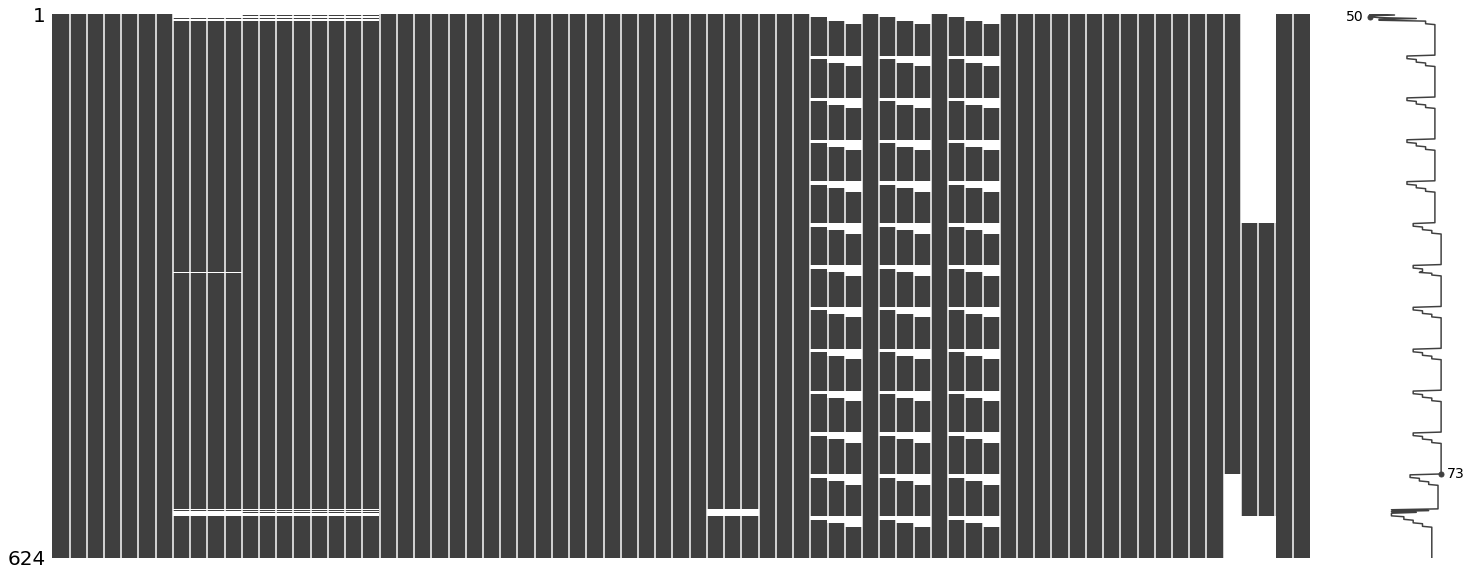

In [145]:
missingno.matrix(dataset_final)

In [146]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)